In [1]:
import sys, os
sys.path.insert(0, r"C:\Users\Dell\Desktop\Rihliq\backend")

print("CWD:", os.getcwd())
print("models/__init__.py exists:", os.path.exists(r"C:\Users\Dell\Desktop\Rihliq\backend\models\__init__.py"))
print("schemas.py exists:", os.path.exists(r"C:\Users\Dell\Desktop\Rihliq\backend\models\schemas.py"))

import models.schemas as s
print("File loaded:", s.__file__)
print("Has AgentState:", hasattr(s, "AgentState"))
print("Names:", [n for n in dir(s) if not n.startswith("_")])

CWD: c:\Users\Dell\Desktop\Rihliq\backend
models/__init__.py exists: True
schemas.py exists: True
File loaded: C:\Users\Dell\Desktop\Rihliq\backend\models\schemas.py
Has AgentState: True
Names: ['AgentState', 'Annotated', 'Any', 'BaseModel', 'ChatRequest', 'Dict', 'Field', 'Flight', 'FlightBaggage', 'FlightSearchRequest', 'Hotel', 'HotelSearchRequest', 'List', 'Literal', 'Location', 'Optional', 'Restaurant', 'RestaurantSearchRequest', 'TripDetails', 'TripParseRequest', 'TripSelections', 'TripSlots', 'Union', 'add_messages', 'annotations']


In [6]:
import os
import logging
from datetime import date
from typing import Dict, Optional
# from datetime import datetime, timedelta
from dotenv import load_dotenv
from pydantic import BaseModel

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver


from models.schemas import (
    AgentState, TripSlots, TripSelections,
    FlightSearchRequest
)
from services.flight_service import search_flights, FlightSearchError
from langchain_groq import ChatGroq

load_dotenv()
logger = logging.getLogger(__name__)


# ─── LLM ──────────────────────────────────────────────────────────────────────

# def get_llm(temperature: float = 0) -> ChatGoogleGenerativeAI:
#     return ChatGoogleGenerativeAI(
#         model="gemini-2.5-flash-lite",
#         temperature=temperature,
#         api_key=os.getenv("GOOGLE_API_KEY"),
#     )

def get_llm(temperature: float = 0) -> ChatGroq:
    return ChatGroq(
        model="openai/gpt-oss-20b",
        temperature=temperature,
        api_key=os.getenv("GROQ_API_KEY"),
    )


# ─── EXTRACTION SCHEMA ────────────────────────────────────────────────────────

class ExtractionResult(BaseModel):
    slots: TripSlots
    selections: TripSelections
    user_pick: Optional[str] = None
    flight_confirmed: Optional[bool] = None

SYSTEM_EXTRACT = """You extract structured data for a travel assistant. You never chat.

Rules:
- Preserve existing values unless the user changes them.
- Dates: YYYY-MM-DD, or null if only a month given. "next week" = 7 days from today.
- num_travelers: "me and my wife"→2, "family of 4"→4, "alone"/"just me"/"solo"→1.
- If user confirms trip details ("yes", "correct", "go ahead") → flight_confirmed=true.
- If user picks a flight (a number, airline name, or ID), put their raw text in user_pick.
- NEVER fill selected_flight_id yourself — the application resolves user_pick to real IDs.
- wants_flights is always true in this mode."""

# ─── HELPERS ──────────────────────────────────────────────────────────────────

def _last_user_text(state: AgentState) -> str:
    for m in reversed(state.messages):
        if isinstance(m, HumanMessage):
            return m.content
    return ""


def _merge(old: BaseModel, new: BaseModel) -> BaseModel:
    """Keep old values when new ones are empty."""
    merged = old.model_dump()
    for k, v in new.model_dump().items():
        if v not in (None, "", [], 0):
            merged[k] = v
    return type(old)(**merged)

def resolve_pick(pick: str, items: list) -> Optional[str]:
    """Match user input to an item id. Tries number, exact id, then name substring."""
    if not pick or not items:
        return None
    pick = pick.strip().lower()

    # Try: "2" → items[1].id
    if pick.isdigit():
        idx = int(pick) - 1
        if 0 <= idx < len(items):
            return items[idx].id

    # Try: exact id match
    for item in items:
        if item.id.lower() == pick:
            return item.id

    # Try: name substring match
    for item in items:
        name = getattr(item, "name", None) or getattr(item, "airline", "")
        if pick in name.lower():
            return item.id

    return None


# ─── NODES ────────────────────────────────────────────────────────────────────

# ─── CHAT PERSONALITY ────────────────────────────────────────────────────────

CHAT_SYSTEM = """You are RihlIQ, a warm, enthusiastic travel concierge. You talk like a friendly human, not a form.

Rules:
- Keep replies to 1-3 short sentences. No bullet lists, no markdown headers.
- Always start with a friendly greeting and introduce yourself as RihlIQ and say that you can help them plan their trip.
- Acknowledge what the user just told you before asking the next thing.
- If brief says "STILL NEED", ask ONE natural question about that item.
- If brief says "READY TO CONFIRM", summarize the trip in one sentence and ask if it's correct.
- If brief says "FLIGHTS FOUND", present the top 5 options warmly, then suggest the best one and ask which they like.
- If brief says "FLIGHT PICKED", congratulate them and wrap up warmly.
- Never invent details — only use what's in the brief."""


def _chat_brief(state: AgentState) -> str:
    """Build a compact internal brief for the chat LLM — flights only."""
    s = state.slots
    sel = state.selections
    lines = []

    # Known info
    known = []
    if s.origin and s.destination:
        known.append(f"{s.origin} → {s.destination}")
    elif s.destination:
        known.append(f"destination: {s.destination}")
    elif s.origin:
        known.append(f"origin: {s.origin}")
    if s.departure_date: known.append(f"depart {s.departure_date}")
    if s.num_travelers and s.num_travelers > 1: known.append(f"{s.num_travelers} travelers")
    if known: lines.append("KNOWN: " + ", ".join(known))

    # What's missing or next
    if not sel.selected_flight_id:
        missing = []
        if not s.origin: missing.append("origin city")
        if not s.destination: missing.append("destination city")
        if not s.departure_date: missing.append("departure date")
        if not s.num_travelers: missing.append("how many people are traveling (just them, or with others)")
        if missing:
            lines.append(f"STILL NEED: {missing[0]}")
        elif not state.flight_confirmed and not state.flights:
            lines.append("READY TO CONFIRM: summarize the trip in one sentence and ask 'is that correct?'")
        elif state.flights and not sel.selected_flight_id:
            top = state.flights[:5]
            fl = []
            for i, f in enumerate(top, 1):
                stops = "direct" if f.stops == 0 else f"{f.stops} stop(s)"
                dep = f.departure_time.replace("T", " ")[:16]
                fl.append(f"  {i}. {f.airline} {f.flight_number} | {dep} | {f.duration} | {stops} | {f.price:.0f} {f.currency}")
            lines.append(f"FLIGHTS FOUND ({len(state.flights)} total, top 5):\n" + "\n".join(fl) + "\n→ Present these and ask which one they'd like.")
    else:
        f = next((x for x in state.flights if x.id == sel.selected_flight_id), None)
        if f:
            lines.append(f"FLIGHT PICKED: {f.airline} {f.flight_number} at {f.price:.0f} {f.currency}. Congratulate them warmly and wrap up.")

    return "\n".join(lines)


async def chat_node(state: AgentState) -> Dict:
    """The warm, human voice of the agent."""
    llm = get_llm(0.7)
    brief = _chat_brief(state)
    history = state.messages[-5:] if state.messages else []

    response = await llm.ainvoke([
        SystemMessage(content=CHAT_SYSTEM),
        *history,
        HumanMessage(content=f"[Internal brief — do not mention to user]\n{brief}\n\nReply to the user now."),
    ])
    return {"messages": [AIMessage(content=response.content)], "next_question": response.content}


async def extractor_node(state: AgentState) -> Dict:
    llm = get_llm(0).with_structured_output(ExtractionResult)
    user_msg = _last_user_text(state)

    result: ExtractionResult = await llm.ainvoke([
        SystemMessage(content=SYSTEM_EXTRACT),
        HumanMessage(content=f"""Today: {date.today()}
            Slots: {state.slots.model_dump_json()}
            Selections: {state.selections.model_dump_json()}
            User said: "{user_msg}" """),
        ])

    # Always flag flights as wanted in this mode
    new_slots = _merge(state.slots, result.slots)
    new_slots.wants_flights = True

    new_selections = _merge(state.selections, result.selections)

    # Resolve the user's pick to a real flight ID
    if result.user_pick and state.flights:
        flight_match = resolve_pick(result.user_pick, state.flights)
        if flight_match:
            new_selections.selected_flight_id = flight_match

    # Sanity check — clear invalid flight IDs the LLM may have hallucinated
    valid_ids = {f.id for f in state.flights}
    if new_selections.selected_flight_id and valid_ids and new_selections.selected_flight_id not in valid_ids:
        new_selections.selected_flight_id = None

    update = {
        "slots": new_slots,
        "selections": new_selections,
    }
    if result.flight_confirmed is True:
        update["flight_confirmed"] = True
    return update


async def flight_search_node(state: AgentState) -> Dict:
    req = FlightSearchRequest(
        origin=state.slots.origin,
        destination=state.slots.destination,
        departure_date=state.slots.departure_date,
        return_date=state.slots.return_date,
        num_travelers=state.slots.num_travelers,
        travel_class=state.slots.travel_class,
    )
    try:
        flights = await search_flights(req)
    except FlightSearchError as e:
        msg = f"Hmm, I couldn't find flights — {e}. Could you double-check the cities and date?"
        return {"flights": [], "messages": [AIMessage(content=msg)], "next_question": msg}

    # Just return the data. chat_node will present it warmly.
    return {"flights": flights, "current_phase": "flights"}

# ─── ROUTER ───────────────────────────────────────────────────────────────────

def router(state: AgentState) -> str:
    s = state.slots
    sel = state.selections

    if not s.origin or not s.destination or not s.departure_date or not s.num_travelers:
        return "chat"
    if not state.flight_confirmed:
        return "chat"
    if not state.flights:
        return "flight_search"
    return "chat"  # either present results, or user already picked

# ─── GRAPH ────────────────────────────────────────────────────────────────────

def create_travel_graph():
    g = StateGraph(AgentState)

    g.add_node("extractor", extractor_node)
    g.add_node("chat", chat_node)
    g.add_node("flight_search", flight_search_node)

    g.set_entry_point("extractor")

    g.add_conditional_edges(
        "extractor",
        router,
        {
            "chat": "chat",
            "flight_search": "flight_search",
        },
    )

    g.add_edge("flight_search", "chat")
    g.add_edge("chat", END)

    return g.compile(checkpointer=MemorySaver())

# ─── INTERFACE ────────────────────────────────────────────────────────────────

class TravelAssistant:
    def __init__(self):
        self.graph = create_travel_graph()

    async def process_message(self, user_msg: str, thread_id: str) -> AgentState:
        config = {"configurable": {"thread_id": thread_id}}
        result = await self.graph.ainvoke(
            {"messages": [HumanMessage(content=user_msg)]},
            config=config,
        )
        return result if isinstance(result, AgentState) else AgentState(**result)


travel_assistant = TravelAssistant()

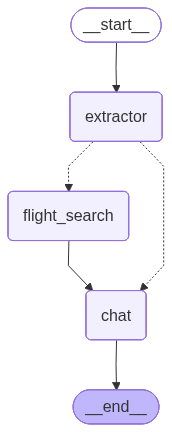

In [7]:
from IPython.display import Image, display

# inside your create_travel_graph() or after compiling:
display(Image(travel_assistant.graph.get_graph().draw_mermaid_png()))